# <center>Clustering Analysis<center>

<p>Team Name: Group 2
<p>Student Names: Aitana Darder, Alex Martrain, Hunter Fernandez

## Instructions
Use generic coding style unless hard-coded values are really necessary.<br>
Your code must be efficient and use self-explanatory naming.<br>
Use appropriate Python library methods for each task instead of using loops.<br>
Run your entire code and save. Then submit this <b>saved</b> copy.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Read Data

In [2]:
data_path = "../data/raw/dataset.csv"

spotify_df = pd.read_csv(data_path)

spotify_df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
print("Dataset shape:", spotify_df.shape)
print("\nColumn names:")
print(spotify_df.columns.tolist())

Dataset shape: (114000, 21)

Column names:
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [4]:
spotify_df.info()

spotify_df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,NaN,NaN,NaN,56999.5,32909.109681,0.0,28499.75,56999.5,85499.25,113999.0
track_id,114000,89741,6S3JlDAGk3uu3NtZbPnuhS,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artists,113999,31437,The Beatles,279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
album_name,113999,46589,Alternative Christmas 2022,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_name,113999,73608,Run Rudolph Run,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,114000.0,NaN,NaN,NaN,33.238535,22.305078,0.0,17.0,35.0,50.0,100.0
duration_ms,114000.0,NaN,NaN,NaN,228029.153114,107297.712645,0.0,174066.0,212906.0,261506.0,5237295.0
explicit,114000,2,False,104253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,114000.0,NaN,NaN,NaN,0.5668,0.173542,0.0,0.456,0.58,0.695,0.985
energy,114000.0,NaN,NaN,NaN,0.641383,0.251529,0.0,0.472,0.685,0.854,1.0


In [6]:
print("Missing values:")
print(spotify_df.isnull().sum())

print("\nDuplicate rows:")
print(spotify_df.duplicated().sum())

Missing values:
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Duplicate rows:
0


## Visual Exploration of Data

### Histograms

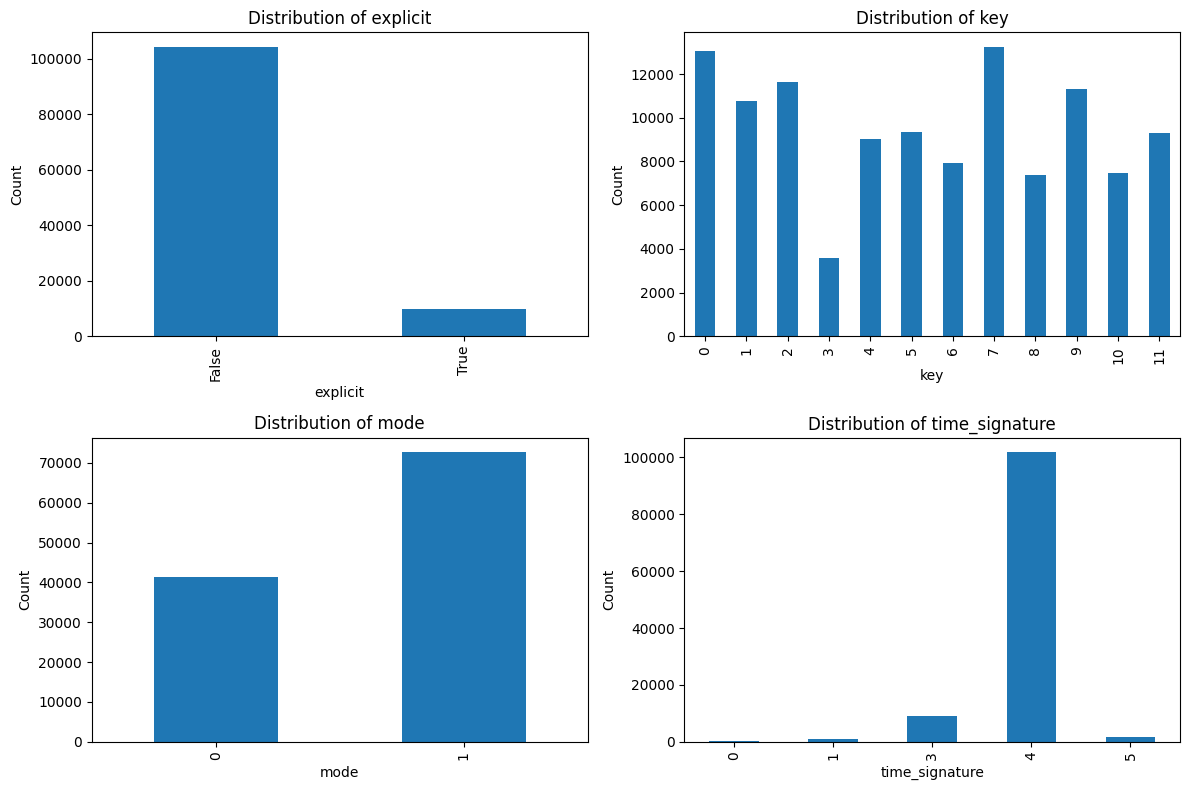

Text(0, 0.5, 'Genre')

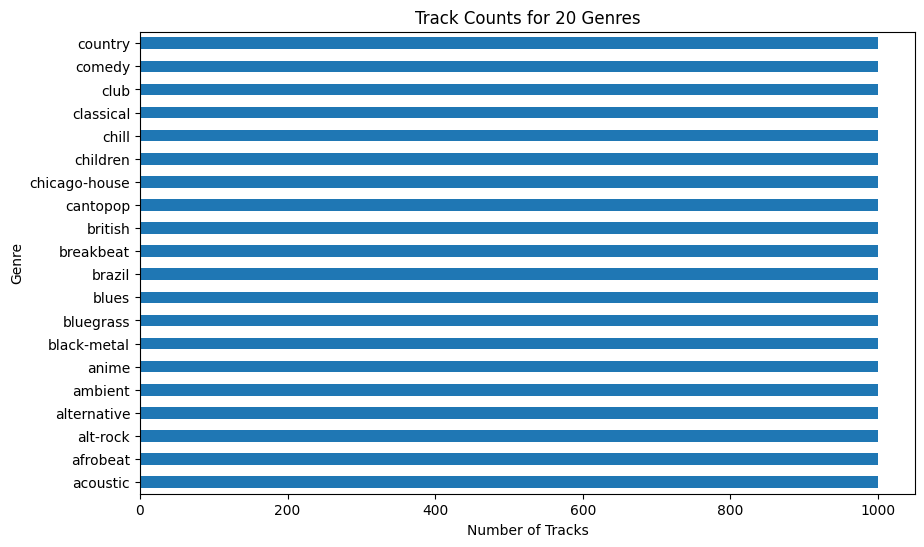

In [14]:
categorical_features = [
    "explicit",
    "key",
    "mode",
    "time_signature"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for feature, ax in zip(categorical_features, axes.flatten()):
    spotify_df[feature].value_counts().sort_index().plot(
        kind="bar",
        ax=ax,
    )

    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

top_genres = spotify_df["track_genre"].value_counts().head(20)

plt.figure(figsize=(10, 6))

top_genres.sort_values().plot(kind="barh")

plt.title("Track Counts for 20 Genres")
plt.xlabel("Number of Tracks")
plt.ylabel("Genre")

### Categorical Feature Observations

The categorical attributes were examined to understand how different types of songs are represented in the dataset.

- Explicit: Most tracks are not marked as explicit. Only a relatively small portion of the      dataset contains explicit content.

- Key: Tracks occur in all 12 musical keys, although some keys appear more often than others.

- Mode: More tracks use major mode than minor mode.

- Time Signature: Most tracks use a 4/4 time signature. Other time signatures, such as 3/4 and 5/4, occur much less.

- Track Genre: The datset containes 114 genres. Each genre contains sbout 1,000 tracks.

### Distributions

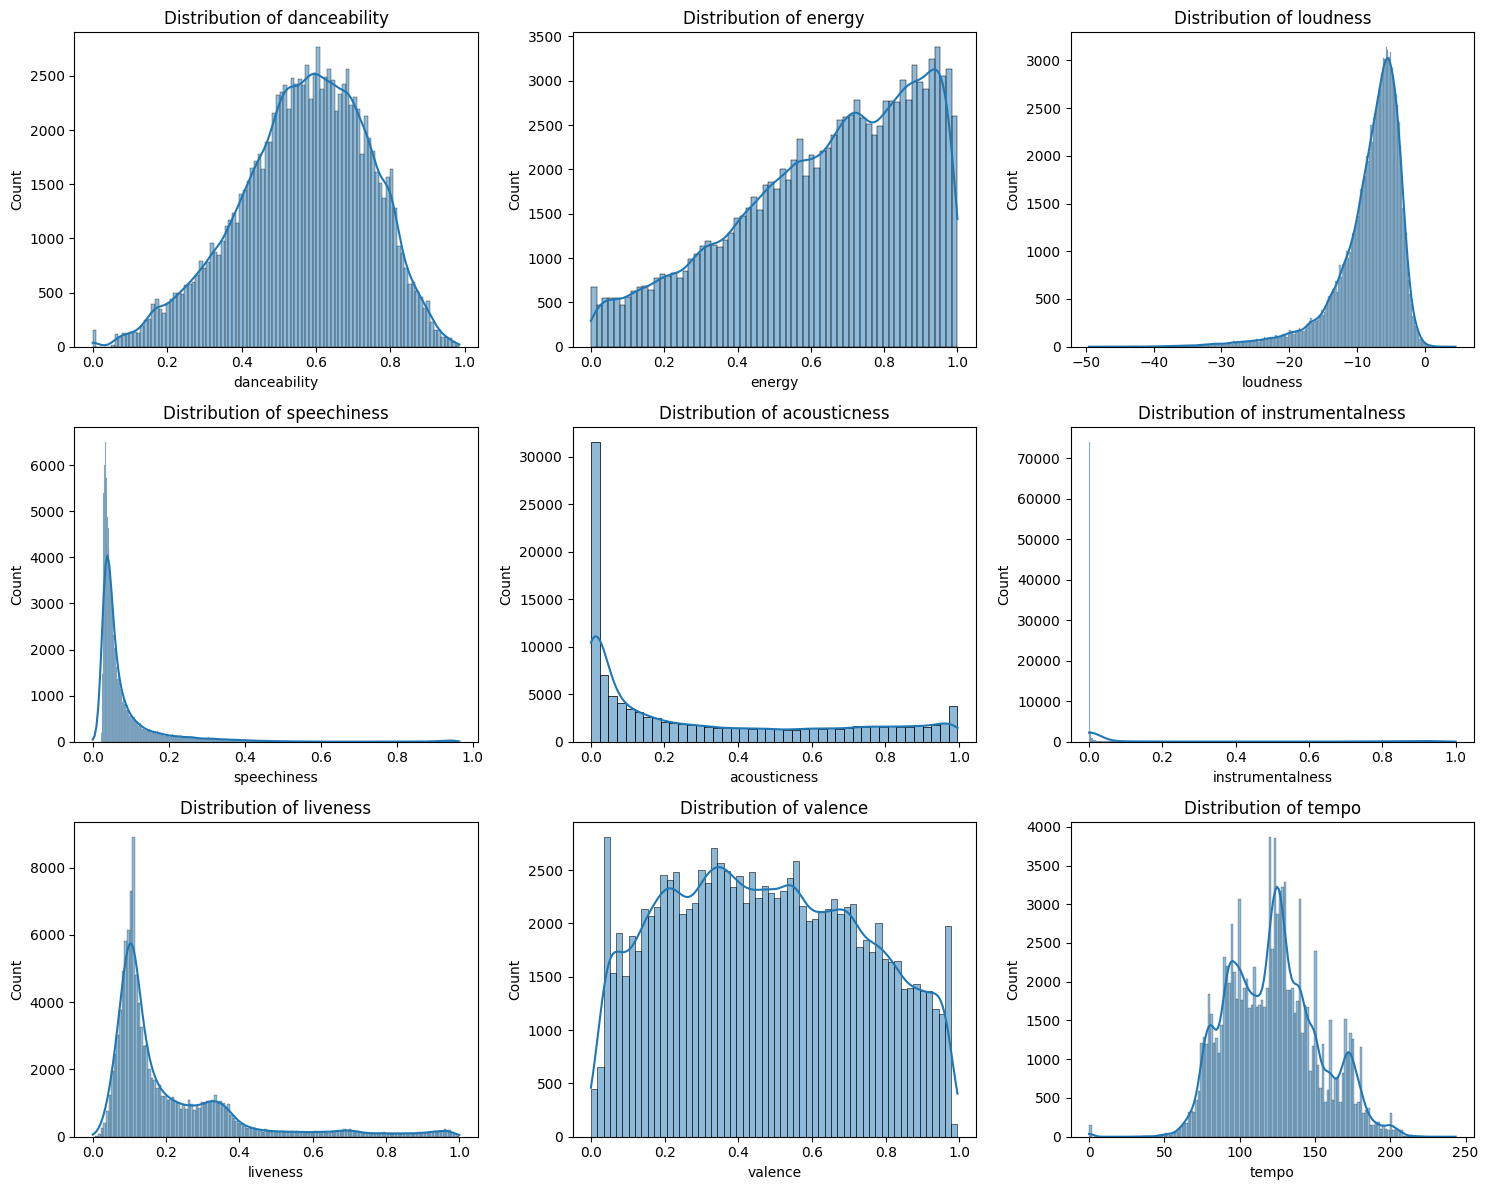

In [16]:
audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for feature, ax in zip(audio_features, axes.flatten()):
    sns.histplot(
        data=spotify_df,
        x=feature,
        kde=True,
        ax=ax
    )

    ax.set_title(f"Distribution of {feature}")

plt.tight_layout()
plt.show()

### Box-Whisker Plots

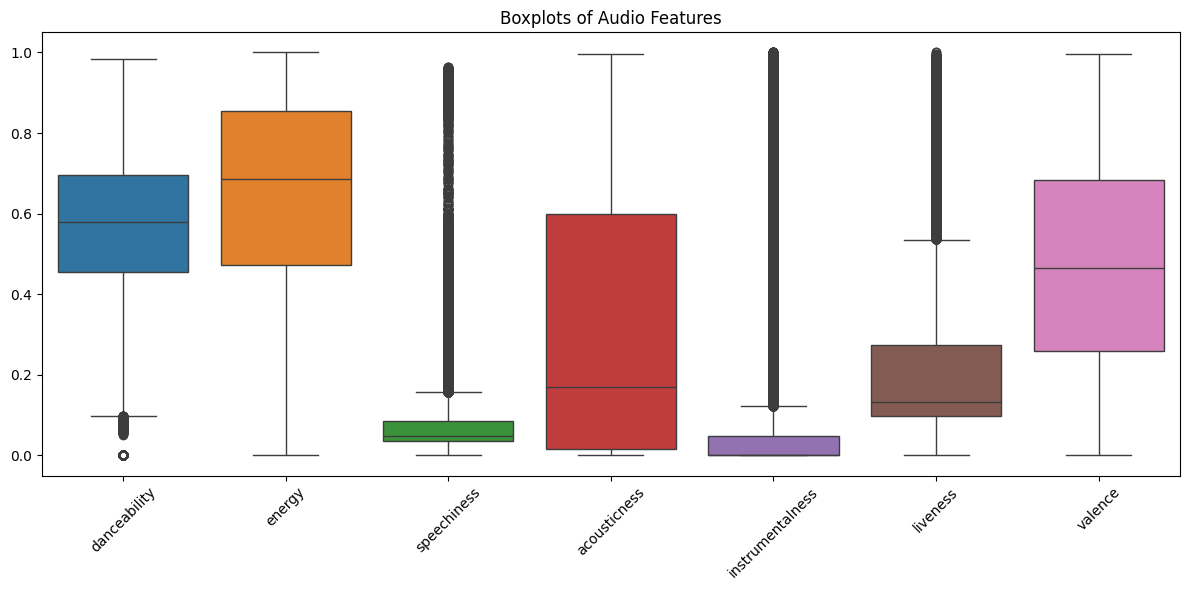

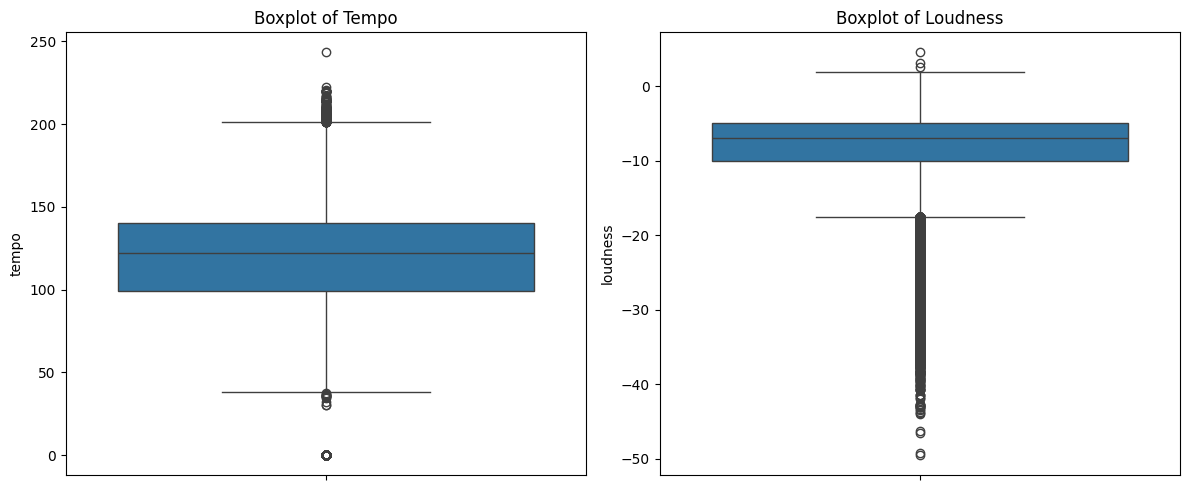

In [17]:
bounded_features = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence"
]

plt.figure(figsize=(12, 6))

sns.boxplot(data=spotify_df[bounded_features])

plt.title("Boxplots of Audio Features")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=spotify_df["tempo"], ax=axes[0])
axes[0].set_title("Boxplot of Tempo")

sns.boxplot(y=spotify_df["loudness"], ax=axes[1])
axes[1].set_title("Boxplot of Loudness")

plt.tight_layout()
plt.show()

### Violin Plots

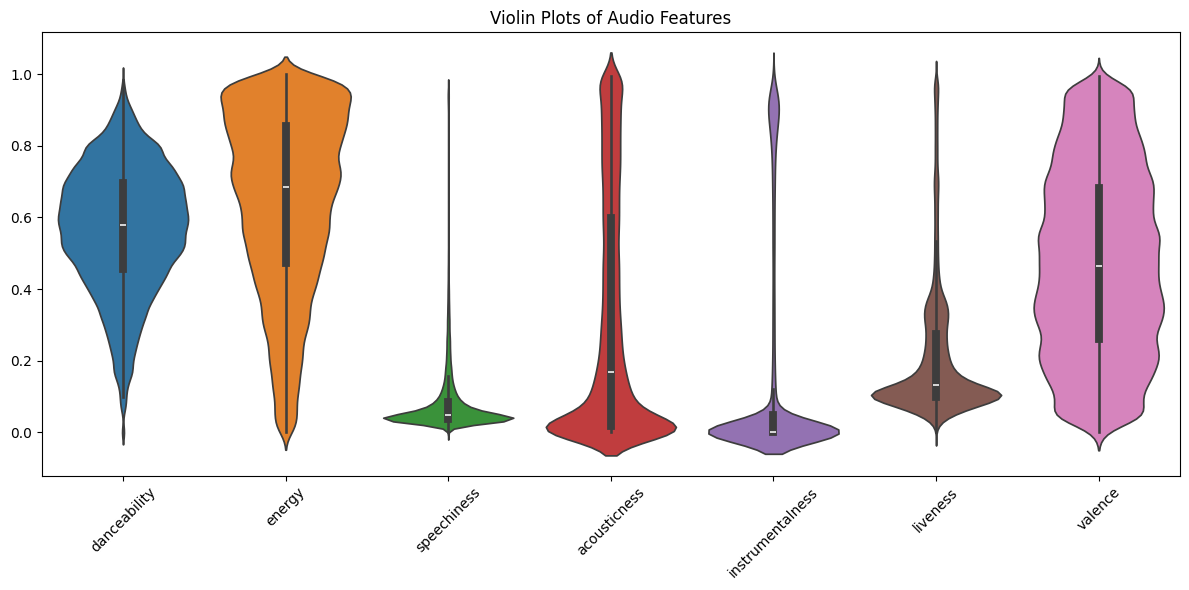

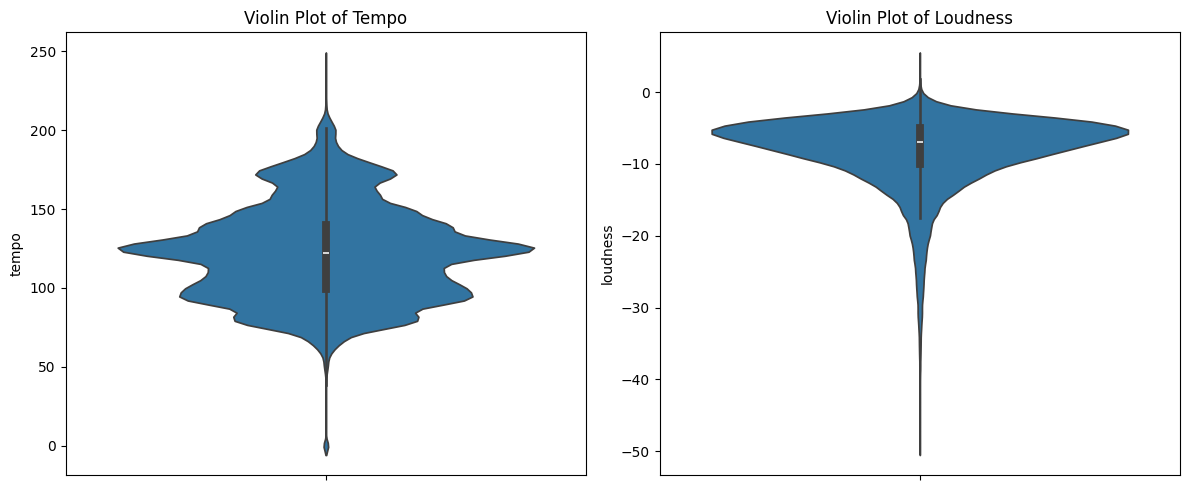

In [18]:
bounded_features = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence"
]

plt.figure(figsize=(12, 6))

sns.violinplot(data=spotify_df[bounded_features])

plt.title("Violin Plots of Audio Features")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.violinplot(y=spotify_df["tempo"], ax=axes[0])
axes[0].set_title("Violin Plot of Tempo")

sns.violinplot(y=spotify_df["loudness"], ax=axes[1])
axes[1].set_title("Violin Plot of Loudness")

plt.tight_layout()
plt.show()

## Data Quality & Cleaning

Instruction: Add a comment for each method

## Handling Redundancy

### X-square Test

### Correlation Analysis

### Visual Exploration (scatter-plot matrix)

## Dimensionality Reduction

### PCA

## Discretization

### Histogram of Discretized Attribute

### X-square Test of Discretized Attributes

### Visual Exploration (scatter-plot matrix) of Discretized Attributes

## Feature Selection/Generation

### Select Features

### Generate Features

# Generate Clusters

## K-means

## Hierarchical

# Evaluation of Clusters

See instructions provided in the report template

## <center> REFERENCES </center>
List resources (book, internet page, etc.) that you used to complete this challenge.